# SmolyakPolyInterp Benchmark Notebook

This notebook benchmarks the end-to-end `grid building + training` pipeline of `SmolyakPolyInterp` for a range of problem dimensionalities and Smolyak accuracy settings.

The benchmark is intentionally moderate so it can finish in finite time on a typical workstation:

- dimensionalities up to 10,
- low-to-moderate accuracy values,
- fixed isotropic levels chosen to keep the sparse-grid size manageable.

The key result is a family of curves showing how runtime and approximation error grow with dimension for each accuracy level.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import smolyakpoly as slp

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


In [2]:
@dataclass
class BenchmarkConfig:
    dims: tuple[int, ...] = (2, 4, 6, 8)
    accuracies: tuple[int, ...] = (1, 3, 5)
    level: int = 3
    repeats: int = 3
    eval_points: int = 2000


cfg = BenchmarkConfig()
cfg


BenchmarkConfig(dims=(2, 4, 6, 8), accuracies=(1, 3, 5), level=3, repeats=3, eval_points=2000)

In [4]:
def make_bounds(dim: int):
    lb = np.linspace(-2.0, -0.5, dim)
    ub = np.linspace(1.0, 2.5, dim)
    return tuple(lb), tuple(ub)


def make_benchmark_function(dim: int):
    weights = np.linspace(0.9, 2.1, dim)
    pair_weights = np.linspace(0.25, 0.65, max(dim - 1, 1))

    def f(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        val = np.sum(np.sin(weights * x) + 0.25 * np.cos((weights + 0.6) * x ** 2))
        if dim > 1:
            val += np.sum(np.sin(pair_weights[: dim - 1] * x[:-1] * x[1:]))
            val += 0.1 * np.sum(x[:-1] ** 2 * x[1:])
        return float(val)

    return f


def run_one_benchmark(dim: int, accuracy: int, level: int, repeats: int = 3, eval_points: int = 2000):
    lb, ub = make_bounds(dim)
    levels = (level,) * dim
    func = make_benchmark_function(dim)
    rng = np.random.default_rng(10_000 + 100 * dim + accuracy)
    X_eval = rng.uniform(np.asarray(lb), np.asarray(ub), size=(eval_points, dim))
    y_true = np.asarray([func(x) for x in X_eval], dtype=float)

    records = []
    for rep in range(repeats):
        t0 = perf_counter()
        interp = slp.SmolyakPolyInterp(
            levels=levels,
            lb=lb,
            ub=ub,
            accuracy=accuracy,
            showtrace=False,
        )
        t1 = perf_counter()
        interp.fit(func, showtrace=False)
        t2 = perf_counter()
        y_pred = interp(X_eval)
        abs_err = np.abs(y_pred - y_true)

        records.append(
            {
                'dim': dim,
                'accuracy': accuracy,
                'repeat': rep,
                'n_nodes': interp.nodes().shape[0],
                'n_basis': interp.coef().shape[0],
                'build_seconds': t1 - t0,
                'fit_seconds': t2 - t1,
                'total_seconds': t2 - t0,
                'max_abs_error': float(np.max(abs_err)),
                'rmse': float(np.sqrt(np.mean((y_pred - y_true) ** 2))),
            }
        )

    return records


def run_benchmark_suite(cfg: BenchmarkConfig):
    rows = []
    total_cases = len(cfg.dims) * len(cfg.accuracies)
    case_id = 0

    for accuracy in cfg.accuracies:
        for dim in cfg.dims:
            case_id += 1
            print(f'[{case_id}/{total_cases}] dim={dim}, accuracy={accuracy}, levels={(cfg.level,) * dim}')
            rows.extend(
                run_one_benchmark(
                    dim=dim,
                    accuracy=accuracy,
                    level=cfg.level,
                    repeats=cfg.repeats,
                    eval_points=cfg.eval_points,
                )
            )

    return pd.DataFrame(rows)


## Run the benchmark

The default configuration below is still finite, but the wider accuracy sweep is noticeably heavier than before. If you want a faster run, reduce `repeats`, `eval_points`, or trim the largest dimensions. If you want a more demanding run, increase `level`, but sparse-grid size can rise quickly.


In [5]:
raw_results = run_benchmark_suite(cfg)
raw_results.head()


[1/12] dim=2, accuracy=1, levels=(3, 3)
[2/12] dim=4, accuracy=1, levels=(3, 3, 3, 3)
[3/12] dim=6, accuracy=1, levels=(3, 3, 3, 3, 3, 3)
[4/12] dim=8, accuracy=1, levels=(3, 3, 3, 3, 3, 3, 3, 3)
[5/12] dim=2, accuracy=3, levels=(3, 3)
[6/12] dim=4, accuracy=3, levels=(3, 3, 3, 3)
[7/12] dim=6, accuracy=3, levels=(3, 3, 3, 3, 3, 3)
[8/12] dim=8, accuracy=3, levels=(3, 3, 3, 3, 3, 3, 3, 3)
[9/12] dim=2, accuracy=5, levels=(3, 3)
[10/12] dim=4, accuracy=5, levels=(3, 3, 3, 3)
[11/12] dim=6, accuracy=5, levels=(3, 3, 3, 3, 3, 3)
[12/12] dim=8, accuracy=5, levels=(3, 3, 3, 3, 3, 3, 3, 3)


,dim,accuracy,repeat,n_nodes,n_basis,build_seconds,fit_seconds,total_seconds,max_abs_error,rmse
0,2,1,0,5,5,0.000519,0.000068,0.000586,1.656670,0.516430
1,2,1,1,5,5,0.000860,0.000111,0.000971,1.656670,0.516430
2,2,1,2,5,5,0.000445,0.000104,0.000549,1.656670,0.516430
3,4,1,0,9,9,0.000606,0.000097,0.000703,3.206727,0.971434
4,4,1,1,9,9,0.000393,0.000081,0.000474,3.206727,0.971434


In [6]:
summary = (
    raw_results.groupby(['dim', 'accuracy'], as_index=False)
    .agg(
        n_nodes=('n_nodes', 'first'),
        n_basis=('n_basis', 'first'),
        build_seconds_mean=('build_seconds', 'mean'),
        build_seconds_std=('build_seconds', 'std'),
        fit_seconds_mean=('fit_seconds', 'mean'),
        fit_seconds_std=('fit_seconds', 'std'),
        total_seconds_mean=('total_seconds', 'mean'),
        total_seconds_std=('total_seconds', 'std'),
        max_abs_error_mean=('max_abs_error', 'mean'),
        max_abs_error_std=('max_abs_error', 'std'),
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
    )
    .sort_values(['accuracy', 'dim'])
)

summary


,dim,accuracy,n_nodes,n_basis,build_seconds_mean,build_seconds_std,fit_seconds_mean,fit_seconds_std,total_seconds_mean,total_seconds_std,max_abs_error_mean,max_abs_error_std,rmse_mean,rmse_std
0,2,1,5,5,0.000608,0.000221,0.000094,0.000023,0.000702,0.000234,1.656670,0.0,0.516430,0.0
3,4,1,9,9,0.000453,0.000134,0.000086,0.000009,0.000538,0.000143,3.206727,0.0,0.971434,0.0
6,6,1,13,13,0.000730,0.000252,0.000099,0.000002,0.000829,0.000252,3.859879,0.0,1.373619,0.0
9,8,1,17,17,0.001700,0.000819,0.000223,0.000168,0.001923,0.000957,6.138740,0.0,1.663770,0.0
1,2,3,21,21,0.001287,0.001354,0.000236,0.000137,0.001523,0.001491,0.503032,0.0,0.197603,0.0
4,4,3,121,121,0.006598,0.002054,0.001696,0.000402,0.008295,0.001922,0.850626,0.0,0.242347,0.0
7,6,3,365,365,0.026359,0.020400,0.005131,0.002037,0.031491,0.018537,0.886311,0.0,0.270622,0.0
10,8,3,817,817,0.046827,0.011170,0.011859,0.003149,0.058686,0.013304,1.226405,0.0,0.330125,0.0
2,2,5,25,25,0.001056,0.000471,0.000267,0.000140,0.001322,0.000575,0.504050,0.0,0.192608,0.0
5,4,5,417,417,0.013650,0.009017,0.004974,0.002091,0.018625,0.009371,0.881244,0.0,0.254729,0.0


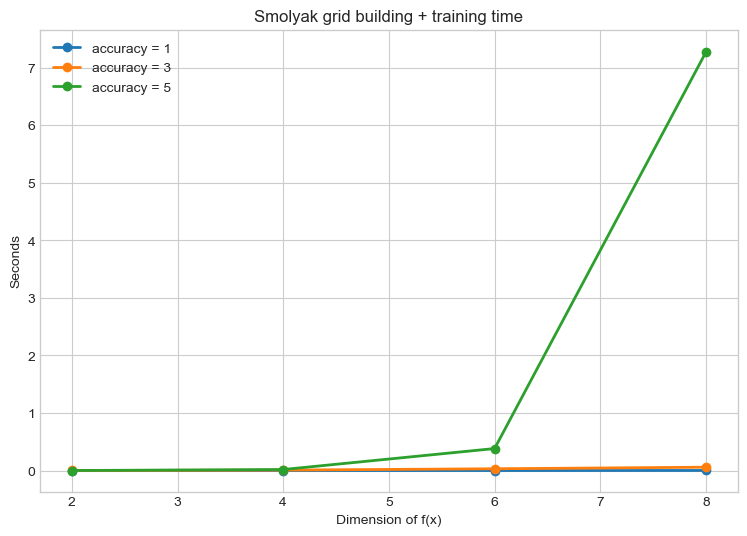

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
for accuracy in cfg.accuracies:
    sub = summary[summary['accuracy'] == accuracy]
    ax.plot(
        sub['dim'],
        sub['total_seconds_mean'],
        marker='o',
        linewidth=2,
        label=f'accuracy = {accuracy}',
    )
    err = sub['total_seconds_std'].fillna(0.0).to_numpy()
    ax.fill_between(
        sub['dim'],
        sub['total_seconds_mean'] - err,
        sub['total_seconds_mean'] + err,
        alpha=0.15,
    )

ax.set_title('Smolyak grid building + training time')
ax.set_xlabel('Dimension of f(x)')
ax.set_ylabel('Seconds')
ax.legend()
plt.show()


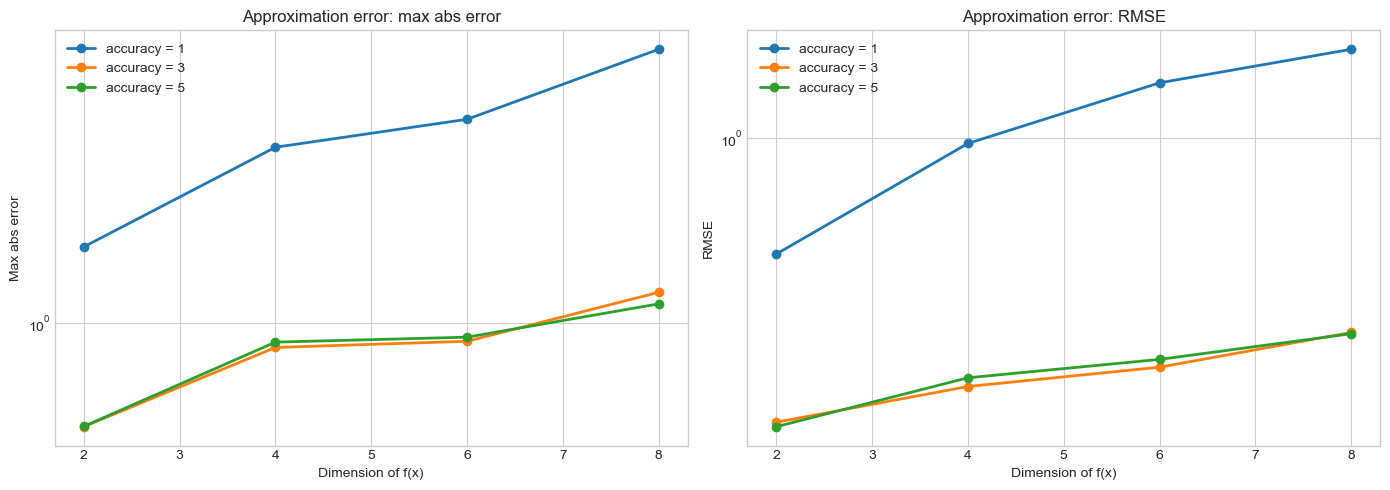

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for accuracy in cfg.accuracies:
    sub = summary[summary['accuracy'] == accuracy]
    axes[0].plot(sub['dim'], sub['max_abs_error_mean'], marker='o', linewidth=2, label=f'accuracy = {accuracy}')
    axes[1].plot(sub['dim'], sub['rmse_mean'], marker='o', linewidth=2, label=f'accuracy = {accuracy}')

axes[0].set_title('Approximation error: max abs error')
axes[0].set_xlabel('Dimension of f(x)')
axes[0].set_ylabel('Max abs error')
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_title('Approximation error: RMSE')
axes[1].set_xlabel('Dimension of f(x)')
axes[1].set_ylabel('RMSE')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()


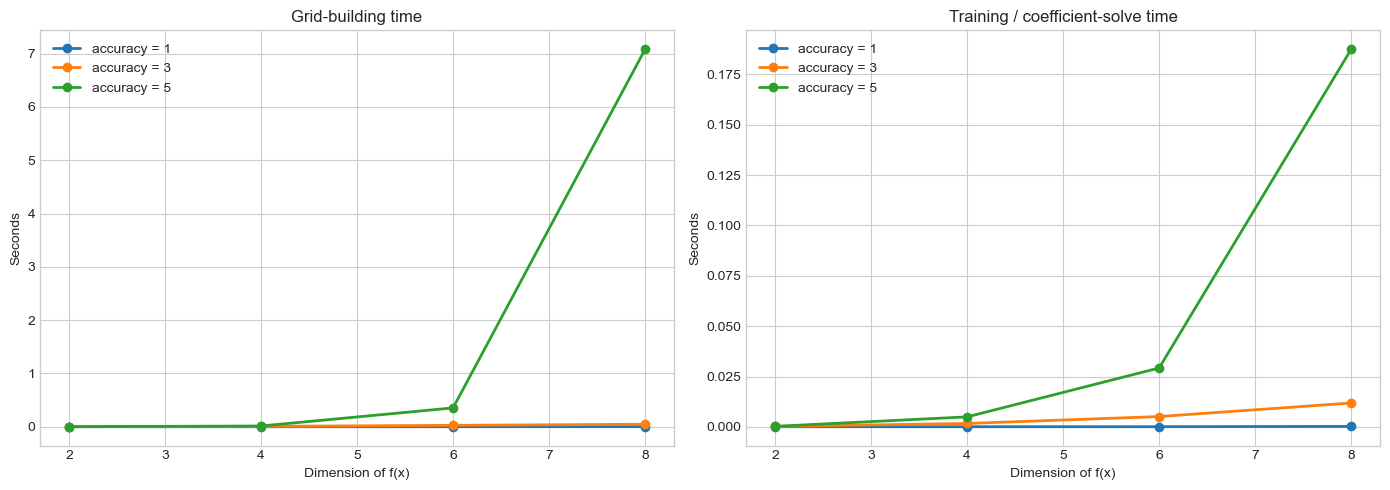

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for accuracy in cfg.accuracies:
    sub = summary[summary['accuracy'] == accuracy]
    axes[0].plot(sub['dim'], sub['build_seconds_mean'], marker='o', linewidth=2, label=f'accuracy = {accuracy}')
    axes[1].plot(sub['dim'], sub['fit_seconds_mean'], marker='o', linewidth=2, label=f'accuracy = {accuracy}')

axes[0].set_title('Grid-building time')
axes[0].set_xlabel('Dimension of f(x)')
axes[0].set_ylabel('Seconds')
axes[0].legend()

axes[1].set_title('Training / coefficient-solve time')
axes[1].set_xlabel('Dimension of f(x)')
axes[1].set_ylabel('Seconds')
axes[1].legend()

plt.tight_layout()
plt.show()


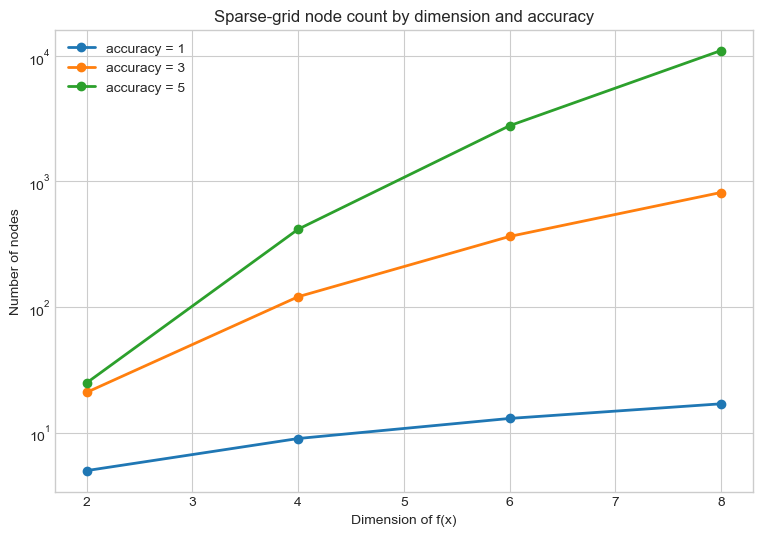

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
for accuracy in cfg.accuracies:
    sub = summary[summary['accuracy'] == accuracy]
    ax.plot(sub['dim'], sub['n_nodes'], marker='o', linewidth=2, label=f'accuracy = {accuracy}')

ax.set_title('Sparse-grid node count by dimension and accuracy')
ax.set_xlabel('Dimension of f(x)')
ax.set_ylabel('Number of nodes')
ax.set_yscale('log')
ax.legend()
plt.show()


In [11]:
pivot_total = summary.pivot(index='dim', columns='accuracy', values='total_seconds_mean')
pivot_nodes = summary.pivot(index='dim', columns='accuracy', values='n_nodes')
pivot_error = summary.pivot(index='dim', columns='accuracy', values='max_abs_error_mean')

print('Mean total seconds')
display(pivot_total)

print('Node counts')
display(pivot_nodes)

print('Mean max abs error')
display(pivot_error)


Mean total seconds


accuracy,1,3,5
dim,,,
2,0.000702,0.001523,0.001322
4,0.000538,0.008295,0.018625
6,0.000829,0.031491,0.382749
8,0.001923,0.058686,7.268294


Node counts


accuracy,1,3,5
dim,,,
2,5,21,25
4,9,121,417
6,13,365,2777
8,17,817,11009


Mean max abs error


accuracy,1,3,5
dim,,,
2,1.656670,0.503032,0.504050
4,3.206727,0.850626,0.881244
6,3.859879,0.886311,0.910627
8,6.138740,1.226405,1.135638
